# Bayesian Optimiser initial tests

I'll test 3 different Bayesian optimisation libraries: `bayes_opt`, `skopt` and `GPyOT` which is an open source constrained global optimisation tool for Python, developed by Fernando Nogueira, 2014.

In order to test the optimiser, I'll use the negative Rastrigin function which has a maximum value of $\textsf{0.0}$ at $\textsf{(x, y) = (0, 0)}$. The function is: $$ z = f(x, y) = 10\left(\cos(2\pi x) + \cos(2\pi y)\right) - \left(x^2 + y^2\right) - 20 $$

This function is used as a hard test to evaluate an optimiser performance as it has lots of local minimum / maximum.

Picture below shows the shape of the function:

In [1]:
import numpy as np
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Plotly (Recommended for Interactive 3D Plot) ---
# This will create a plot you can click, drag, and zoom in your notebook.

# Define the range for x and y
x = np.linspace(-5.12, 5.12, 400)
y = np.linspace(-5.12, 5.12, 400)

# Create a meshgrid, which gives us a coordinate matrix
X, Y = np.meshgrid(x, y)

# Define the negative Rastrigin function
# A is the amplitude, which we'll set to 10 as in the formula
A = 10
Z = (X**2 - A * np.cos(2 * np.pi * X)) + \
    (Y**2 - A * np.cos(2 * np.pi * Y)) + 2 * A

# The standard Rastrigin function is minimized at (0,0).
# To have a function with a global MAXIMUM at (0,0), we simply negate it.
Z_neg = -Z

# Create the 3D surface plot using Plotly
fig_plotly = go.Figure(data=[go.Surface(z=Z_neg, x=X, y=Y,
                                       colorscale='viridis', # A nice color map
                                       colorbar=dict(title='Z value'),
                                       contours=dict(
                                           z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True)
                                       ))])

# Update the layout for a better look
fig_plotly.update_layout(title='Negative Rastrigin Function',
                         scene=dict(
                             xaxis_title='X Axis',
                             yaxis_title='Y Axis',
                             zaxis_title='Z = f(x, y)'),
                         autosize=False,
                         width=800, height=800,
                         margin=dict(l=65, r=50, b=65, t=90))

# Display the plot in a Jupyter Notebook
fig_plotly.show()


## bayes_opt

I'll use `bayes_opt` which is an open source constrained global optimisation tool for Python, developed by Fernando Nogueira, 2014.

In [2]:
from bayes_opt import BayesianOptimization
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# 2D function
def black_box_function(x, y):
    return 10 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)) - (x**2 + y**2) - 20

In [4]:
# Bounds
#pbounds = {'x': (-5.12, 5.12), 'y': (-5.12, 5.12)}
pbounds = {'x': (-2.12, 2.12), 'y': (-2.12, 2.12)}

In [5]:
# Optimiser parameters configuration
optimizer = BayesianOptimization(
    f = black_box_function,
    pbounds = pbounds,
    random_state=49,
)

In [6]:
# Call the optimiser to maximise the function
optimizer.maximize(
    init_points=8,
    n_iter=200,
)
best_params_bayes_opt = optimizer.max['params']
best_value_bayes_opt = optimizer.max['target']

|   iter    |  target   |     x     |     y     |
-------------------------------------------------
| 1         | -7.316814 | -0.843910 | -1.072457 |
| 2         | -27.81746 | 1.8076609 | 1.6603985 |
| 3         | -21.08512 | 0.7770934 | 0.2835909 |
| 4         | -17.01519 | 0.1991353 | -1.227802 |
| 5         | -22.19704 | 1.1437589 | 1.6800156 |
| 6         | -1.595441 | 0.9397979 | -0.005171 |
| 7         | -23.40725 | -0.245017 | 1.2823054 |
| 8         | -27.21805 | 1.4620847 | -1.148454 |
| 9         | -19.15137 | 0.8802615 | 0.6622404 |
| 10        | -29.24814 | -0.249404 | 0.4296445 |
| 11        | -24.32730 | -0.556611 | 2.0479030 |
| 12        | -43.10519 | 1.4792432 | -1.588991 |


| 13        | -5.009244 | 1.0309139 | -0.142307 |
| 14        | -22.47895 | -0.475740 | -0.111520 |
| 15        | -15.83243 | 0.7550040 | -0.176523 |
| 16        | -35.34174 | 1.5881457 | -0.319204 |


| 17        | -5.573053 | 1.1267495 | 0.0817269 |
| 18        | -22.72715 | -0.355825 | -2.102664 |


| 19        | -23.52257 | -0.523434 | -1.105913 |
| 20        | -1.397872 | 0.9525011 | -0.015652 |


| 21        | -9.195409 | -1.190910 | -1.040525 |
| 22        | -21.90716 | -1.040956 | -1.411738 |
| 23        | -12.06431 | -0.972946 | -0.743296 |


...

| 204       | -0.000846 | 0.0015512 | -0.001363 |


| 205       | -0.002615 | -0.002163 | 0.0029156 |


| 206       | -0.000788 | 0.0014400 | -0.001378 |


| 207       | -0.001844 | 0.0019240 | 0.0023659 |


| 208       | -0.001530 | -0.002288 | -0.001574 |


In [7]:
print(best_params_bayes_opt)
print(best_value_bayes_opt)
print(optimizer.max)

{'x': np.float64(0.000882466045901817), 'y': np.float64(-0.00038928286791490327)}
-0.00018456126557708785
{'target': np.float64(-0.00018456126557708785), 'params': {'x': np.float64(0.000882466045901817), 'y': np.float64(-0.00038928286791490327)}}


>⚠️
>
>I tried testing with 64 initial points and 1000 iterations but the optimiser got stuck after around 300 iterations not going beyond the $\textsf{z=-1.0}$ value.

I tried testing with 64 initial points and 1000 iterations but the optimiser got stuck after around 300 iterations not going beyond the $\textsf{z=-1.0}$ value.


|       | maxCellSize | main_walls cellSize | Cells | Gen Time | Notes                             |
| :---: | :---------: | :-----------------: | :---: | :------: | --------------------------------- |
| Try04 |    0.005    |        0.005        | 77.4M |   20 m   | ⚠️ Injection tube was not created |


In [8]:
pbounds

{'x': (-2.12, 2.12), 'y': (-2.12, 2.12)}

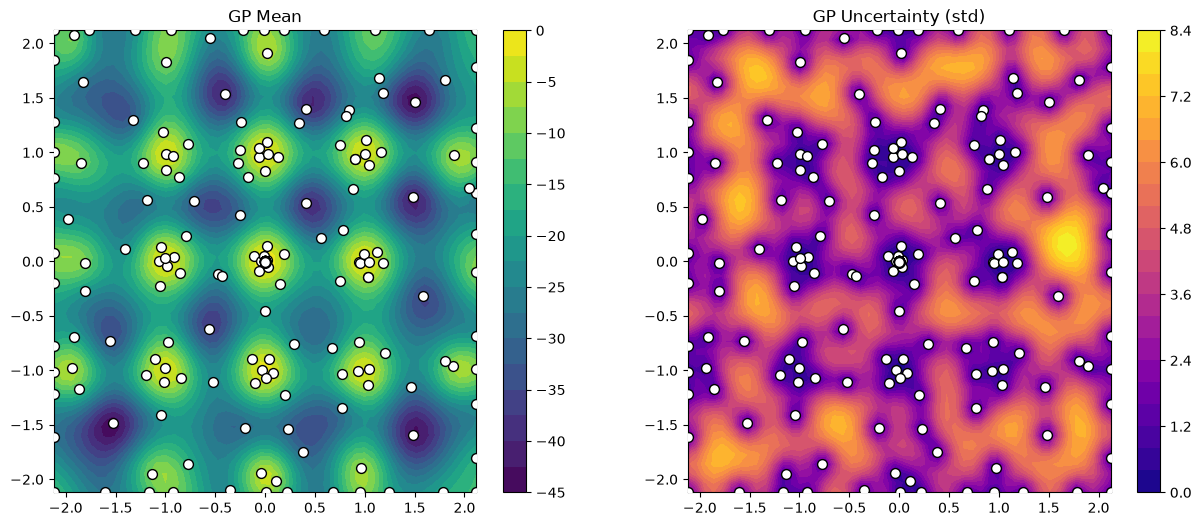

In [9]:
def plot_2d_surrogate(optimizer, pbounds, n_points=50):
    x = np.linspace(pbounds['x'][0], pbounds['x'][1], n_points)
    y = np.linspace(pbounds['y'][0], pbounds['y'][1], n_points)
    X, Y = np.meshgrid(x, y)
    
    # Create points for prediction
    points = np.column_stack([X.ravel(), Y.ravel()])
    
    # Predict
    mu, sigma = optimizer._gp.predict(points, return_std=True)
    mu = mu.reshape(X.shape)
    sigma = sigma.reshape(X.shape)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot mean
    im1 = ax1.contourf(X, Y, mu, levels=20, cmap='viridis')
    ax1.set_title('GP Mean')
    plt.colorbar(im1, ax=ax1)
    
    # Plot uncertainty
    im2 = ax2.contourf(X, Y, sigma, levels=20, cmap='plasma')
    ax2.set_title('GP Uncertainty (std)')
    plt.colorbar(im2, ax=ax2)
    
    # Add observed points
    obs_X = optimizer._space.params
    for ax in [ax1, ax2]:
        ax.scatter(obs_X[:, 0], obs_X[:, 1], c='white', 
                  s=50, edgecolors='black', zorder=10)
    
    plt.show()
plot_2d_surrogate(optimizer, pbounds)

## scikit-optimize (`skopt`)

In [10]:
# Install with: pip install scikit-optimize  (the import name is `skopt`)
from skopt import gp_minimize

# gp_minimize MINIMISES and passes the parameters as a single list,
# so we use the (positive) Rastrigin function, whose minimum is 0.0 at (0, 0).
# This is the negative of black_box_function used with bayes_opt above.
def skopt_function(params):
    x, y = params
    return 10 * (2 - np.cos(2 * np.pi * x) - np.cos(2 * np.pi * y)) + (x**2 + y**2)

In [11]:
# Define parameter bounds (same as bayes_opt above)
bounds_skopt = [
    pbounds['x'],  # x
    pbounds['y'],  # y
]

In [12]:
# Run optimization (same budget as bayes_opt: 8 initial points + 200 iterations)
result = gp_minimize(
    skopt_function,
    bounds_skopt,
    n_calls=208,          # Total evaluations
    n_initial_points=8,   # Random initial points
    acq_func="EI",        # Expected Improvement
    random_state=42
)

# Get best result
best_params_skopt = result.x
best_value_skopt = result.fun

In [13]:
print(best_params_skopt)
print(best_value_skopt)
# Value of the negative Rastrigin function, comparable with bayes_opt's target
print(-best_value_skopt)

[0.0006134206192944802, 0.00012425196144372208]
7.771473235956535e-05
-7.771473235956535e-05
